In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

plt.close('all')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100

In [34]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(50, activation='tanh'),
    tf.keras.layers.Dense(1)
])

In [35]:
def pde(x, model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(x)
        y_pred = model(x)
        y_x  = tape.gradient(y_pred, x)
    y_xx = tape.gradient(y_x, x)

    del tape
    return y_xx + np.pi**2 * tf.sin(np.pi * x)

In [36]:
def loss(model, x, x_bc, y_bc):
    res = pde(x, model)

    # PDE loss
    loss_pde = tf.reduce_mean(tf.square(res))

    # Boundary prediction using Sequential model
    y_bc_pred = model(x_bc)

    # Boundary loss
    loss_bc = tf.reduce_mean(tf.square(y_bc - y_bc_pred))

    return loss_pde + loss_bc

In [37]:
def train_step(model, x, x_bc, y_bc, optimizer):
    with tf.GradientTape() as tape:
        loss_value = loss(model, x, x_bc, y_bc)
    
    # Get gradients of the loss w.r.t. the trainable weights
    grads = tape.gradient(loss_value, model.trainable_variables)
    
    # Apply gradients
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss_value

In [39]:
# Setting up the problem

# Generate training data
x_train = np.linspace(-1, 1, 100).reshape(-1, 1)
x_train = tf.convert_to_tensor(x_train, dtype=tf.float32)

# Boundary data
x_bc = np.array([[-1.0], [1.0]], dtype=np.float32)
y_bc = np.array([[0.0], [0.0]], dtype=np.float32)
x_bc = tf.convert_to_tensor(x_bc, dtype=tf.float32)
y_bc = tf.convert_to_tensor(y_bc, dtype=tf.float32)


# Define the optimizer with a learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=1000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Train the model
epochs = 2000
for epoch in range(epochs):
    # Pass the 'model' object itself, not 'model()'
    loss_value = train_step(model, x_train, x_bc, y_bc, optimizer)
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}: Loss = {loss_value.numpy():.4e}")

Epoch 0: Loss = 4.8181e+01
Epoch 200: Loss = 2.7815e-02
Epoch 400: Loss = 5.8100e-03
Epoch 600: Loss = 2.4421e-03
Epoch 800: Loss = 1.6858e-03
Epoch 1000: Loss = 1.2177e-03
Epoch 1200: Loss = 8.4544e-04
Epoch 1400: Loss = 5.7486e-04
Epoch 1600: Loss = 3.9618e-04
Epoch 1800: Loss = 2.8799e-04


In [41]:
# Predict the solution
x_test = np.linspace(-1, 1, 1000).reshape(-1, 1)
x_test = tf.convert_to_tensor(x_test, dtype=tf.float32)

# Use the model directly
y_pred = model(x_test).numpy()

# Analytical solution
y_true = np.sin(np.pi * x_test)

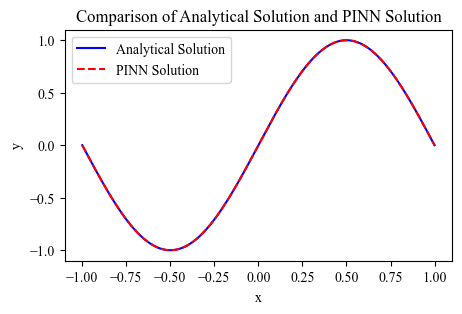

In [42]:
# Plot the results
plt.figure(figsize=(5, 3))
plt.plot(x_test, y_true, 'b-', label='Analytical Solution')
plt.plot(x_test, y_pred, 'r--', label='PINN Solution')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.title('Comparison of Analytical Solution and PINN Solution')
plt.show()